In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm import tqdm

from net import net

In [ ]:
domain_length = 6.0
domain_width = 2.0
obstacle_x0 = 2.0
obstacle_x1 = 3.0
obstacle_y0 = 0.0
obstacle_y1 = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x_min, x_max = 0.0, domain_length
y_min, y_max = 0.0, domain_width
nx, ny = 60, 40

x_centers = np.linspace(x_min + (x_max - x_min)/(2*nx), x_max - (x_max - x_min)/(2*nx), nx, dtype=np.float32)
y_centers = np.linspace(y_min + (y_max - y_min)/(2*ny), y_max - (y_max - y_min)/(2*ny), ny, dtype=np.float32)
X_grid, Y_grid = np.meshgrid(x_centers, y_centers)

def magnitude(vector_field):
    reshaped = vector_field.reshape((ny, nx, 2))
    x = reshaped[:, :, 0]
    y = reshaped[:, :, 1]
    return np.sqrt(x**2 + y**2)

Using device: cuda


In [ ]:
# Training hyperparameters
LEARNING_RATE = 1e-4
BATCH_SIZE = 2**20
EPOCHS = 1000
TRAINING_OUTPUT_DIR = "train_dir_pytorch/"
MODEL_BASE_NAME = "ns_obstacle_pytorch_norm"

data_npz = np.load('training_data.npz')
X_train_np = data_npz['X_train'].astype(np.float32)
Y_train_np = data_npz['Y_train'].astype(np.float32)

#filter out the data points that are inside the obstacle
obstacle_mask = ~((X_train_np[:, 0] >= obstacle_x0) & (X_train_np[:, 0] <= obstacle_x1) &
                  (X_train_np[:, 1] >= obstacle_y0) & (X_train_np[:, 1] <= obstacle_y1))
X_train_np = X_train_np[obstacle_mask]
Y_train_np = Y_train_np[obstacle_mask]

train_dataset = TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(Y_train_np))
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

model = net.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5, verbose=True)

print("Starting training...")
os.makedirs(TRAINING_OUTPUT_DIR, exist_ok=True)
best_loss = float('inf')
loss_history = []
patience = 0
early_stopping = 50

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_epoch_loss)
    scheduler.step(avg_epoch_loss) # LR scheduler step

    print(f"Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_epoch_loss:.8f}")

    # Save checkpoint if it's the best model so far
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience = 0

        if epoch > 200:
            checkpoint_path = os.path.join(TRAINING_OUTPUT_DIR, f"{MODEL_BASE_NAME}_best.pt")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"New best model saved to {checkpoint_path} with loss {best_loss:.8f}")
    else:
        patience += 1
        if patience >= early_stopping:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

print("Training finished.")

Loading data...
Data loaded. X_train shape: (4800000, 3), Y_train shape: (4800000, 3)


/home/dan/venvs/torch/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...


Epoch [1/1000], Average Loss: 0.43163560


Epoch [2/1000], Average Loss: 0.31351290


...

Epoch [10/1000], Average Loss: 0.14244764


Epoch [11/1000], Average Loss: 0.13920326


Epoch [12/1000], Average Loss: 0.13617921


Epoch [13/1000], Average Loss: 0.13308453


Epoch 14/1000:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
final_model_path = os.path.join(TRAINING_OUTPUT_DIR, f"{MODEL_BASE_NAME}_final.pt")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to: {final_model_path}")

NameError: name 'os' is not defined

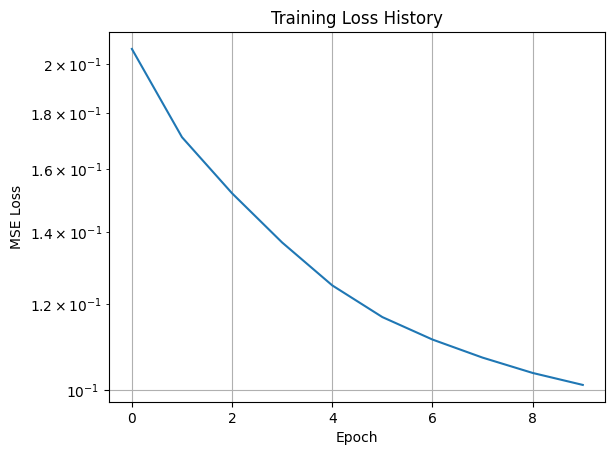

Generating predictions and animations...


Sequential(
  (0): Linear(in_features=3, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): Tanh()
  (4): Linear(in_features=32, out_features=32, bias=True)
  (5): Tanh()
  (6): Linear(in_features=32, out_features=64, bias=True)
  (7): Tanh()
  (8): Linear(in_features=64, out_features=64, bias=True)
  (9): Tanh()
  (10): Linear(in_features=64, out_features=32, bias=True)
  (11): Tanh()
  (12): Linear(in_features=32, out_features=32, bias=True)
  (13): Tanh()
  (14): Linear(in_features=32, out_features=32, bias=True)
  (15): Tanh()
  (16): Linear(in_features=32, out_features=3, bias=True)
)

In [ ]:
plt.figure()
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss History')
plt.yscale('log')
plt.grid(True)
plt.savefig(os.path.join(TRAINING_OUTPUT_DIR, "loss_history.png"))
plt.show()

# --- Prediction and Visualization ---
print("Generating predictions and animations...")
model.eval() # Set model to evaluation mode

In [ ]:
def model_predict(x_mesh, y_mesh, time=0.0):
    n_points_mesh = len(x_mesh.flatten())
    t_values_mesh = np.full(n_points_mesh, time, dtype=np.float32)
    
    points_to_predict_np = np.vstack((x_mesh.flatten(), y_mesh.flatten(), t_values_mesh)).T
    points_to_predict_torch = torch.from_numpy(points_to_predict_np).to(device)

    with torch.no_grad():
        predictions = model(points_to_predict_torch).cpu().numpy()

    u_pred = predictions[:, 0].reshape(x_mesh.shape)
    v_pred = predictions[:, 1].reshape(x_mesh.shape)
    p_pred = predictions[:, 2].reshape(x_mesh.shape)

    Velocity = np.column_stack([u_pred.flatten(), v_pred.flatten()])
    Pressure = p_pred.flatten()

    return Velocity, Pressure

In [ ]:
def update_plot(ax, field_data, time_value, field_name, vmin=None, vmax=None, cmap='coolwarm'):
    ax.clear()
    field_reshaped = field_data.reshape(ny, nx)

    im = ax.imshow(field_reshaped, cmap=cmap, origin='lower',
                   extent=(x_min, x_max, y_min, y_max),
                   vmin=vmin, vmax=vmax)
    
    obstacle_patch = plt.Rectangle((obstacle_x0, obstacle_y0),
                                  obstacle_x1-obstacle_x0,
                                  obstacle_y1-obstacle_y0,
                                  color='white', alpha=0.7)
    ax.add_patch(obstacle_patch)
    ax.set_title(f'{field_name} at t = {time_value:.2f}s')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    return [im]

In [ ]:
time_points = np.linspace(0, 10, 200, dtype=np.float32)
nn_vel_mags = []
nn_pressures = []

for t in tqdm(time_points, desc="Generating animation frames"):
    vel, press = model_predict(X_grid, Y_grid, time=t)
    nn_vel_mags.append(magnitude(vel).flatten())
    nn_pressures.append(press)

fig_vel, ax_vel = plt.subplots(figsize=(10, 6))
vmin_vel, vmax_vel = np.min(nn_vel_mags), np.max(nn_vel_mags)
def animate_velocity(frame):
    return update_plot(ax_vel, nn_vel_mags[frame], time_points[frame], 'NN Velocity Magnitude', vmin=vmin_vel, vmax=vmax_vel)
ani_vel = FuncAnimation(fig_vel, animate_velocity, frames=len(time_points), blit=False)
ani_vel.save(os.path.join(TRAINING_OUTPUT_DIR, 'nn_velocity_animation.mp4'), writer='ffmpeg', fps=20)
plt.close(fig_vel)
print("Velocity animation saved.")

fig_press, ax_press = plt.subplots(figsize=(10, 6))
vmin_press, vmax_press = np.min(nn_pressures), np.max(nn_pressures)
def animate_pressure(frame):
    return update_plot(ax_press, nn_pressures[frame], time_points[frame], 'NN Pressure', vmin=vmin_press, vmax=vmax_press, cmap='RdBu_r')
ani_press = FuncAnimation(fig_press, animate_pressure, frames=len(time_points), blit=False)
ani_press.save(os.path.join(TRAINING_OUTPUT_DIR, 'nn_pressure_animation.mp4'), writer='ffmpeg', fps=20)
plt.close(fig_press)
print("Pressure animation saved.")

Generating animation frames: 100%|██████████| 200/200 [00:00<00:00, 2659.60it/s]


Velocity animation saved.
Pressure animation saved.


In [ ]:
!jupyter nbconvert --to script 'offline-training-no-deepxde.ipynb'

[NbConvertApp] Converting notebook offline-training-no-deepxde.ipynb to script
[NbConvertApp] Writing 7381 bytes to offline-training-no-deepxde.py
